[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_372/2376989676.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"SPY Sharpe Ratio (annualised): {float(sharpe_ratio):.4f}")
/tmp/ipykernel_372/2376989676.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"SPY Maximum Drawdown:          {float(max_drawdown):.2%}")


SPY Sharpe Ratio (annualised): 0.5308
SPY Maximum Drawdown:          -33.72%


<Figure size 1200x400 with 0 Axes>

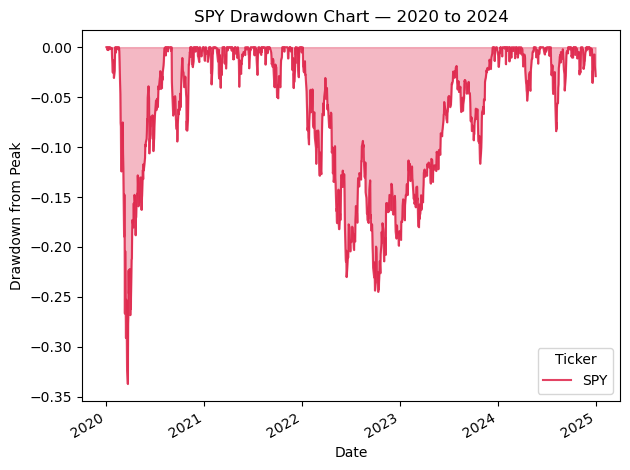

/tmp/ipykernel_372/2376989676.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"SPY Annualised Return:         {float(annualised_ret):.2%}")
/tmp/ipykernel_372/2376989676.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  last_price = float(spy["Close"].iloc[-1])


SPY Annualised Return:         14.37%


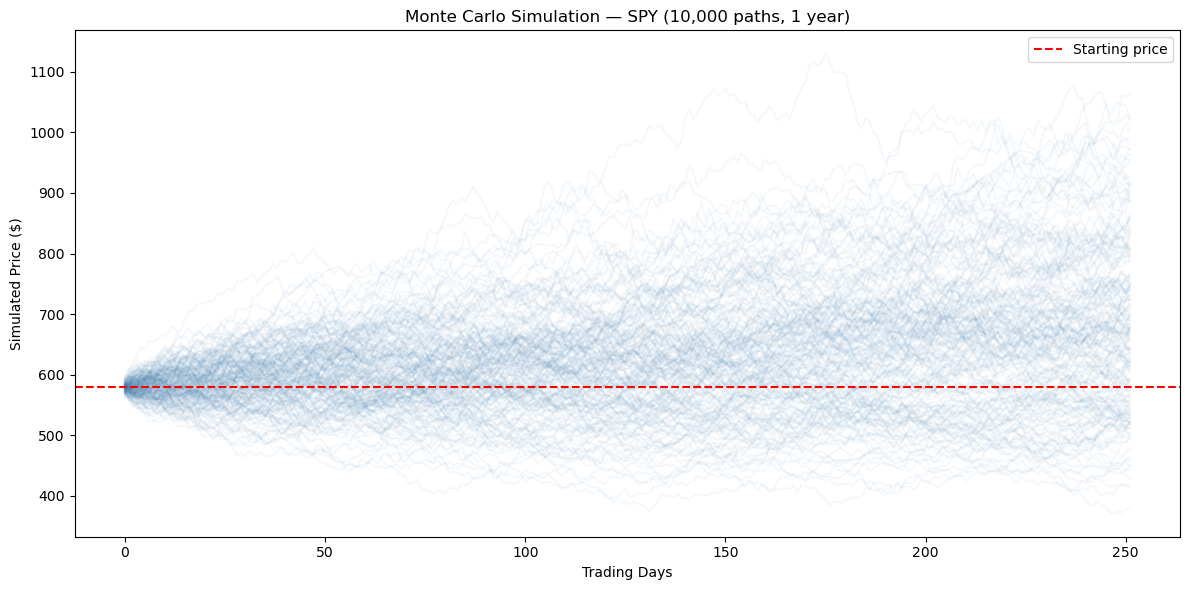

Starting price:                $579.81
Expected 1-year return:        16.74%
95% VaR (1 year):              -19.00%
Best case (95th pct):          61.06%
Median outcome:                14.33%


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Pull SPY data
spy = yf.download("SPY", start="2020-01-01", end="2024-12-31")
returns = spy["Close"].pct_change(fill_method=None).dropna()

# ── Risk Metrics from Historical Returns ───────────────────────

# Sharpe Ratio
risk_free_daily = 0.045 / 252      # 4.5% annual risk-free rate
excess_returns = returns - risk_free_daily
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
print(f"SPY Sharpe Ratio (annualised): {float(sharpe_ratio):.4f}")

# Maximum Drawdown
cumulative = (1 + returns).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()
print(f"SPY Maximum Drawdown:          {float(max_drawdown):.2%}")

# Plot drawdown
plt.figure(figsize=(12, 4))
drawdown.plot(color="crimson", alpha=0.8)
plt.fill_between(
    drawdown.index,
    drawdown.squeeze().values,
    0,
    alpha=0.3,
    color="crimson"
)
plt.title("SPY Drawdown Chart — 2020 to 2024")
plt.ylabel("Drawdown from Peak")
plt.tight_layout()
plt.savefig("kroniq_spy_drawdown.png", dpi=150)
plt.show()

# Annualised Return
total_return = cumulative.iloc[-1] - 1
n_years = len(returns) / 252
annualised_ret = (1 + total_return) ** (1 / n_years) - 1
print(f"SPY Annualised Return:         {float(annualised_ret):.2%}")

# ── Monte Carlo Parameters ─────────────────────────────────────
last_price = float(spy["Close"].iloc[-1])
daily_vol = returns.std()
daily_ret = returns.mean()
n_days = 252
n_sims = 10000

# Run Monte Carlo simulation
np.random.seed(42)
sim_returns = np.random.normal(daily_ret, daily_vol, (n_days, n_sims))
price_paths = last_price * np.cumprod(1 + sim_returns, axis=0)

# Plot 200 of the 10,000 paths
plt.figure(figsize=(12, 6))
plt.plot(price_paths[:, :200], alpha=0.05, color="steelblue")
plt.axhline(last_price, color="red", linestyle="--", linewidth=1.5, label="Starting price")
plt.title("Monte Carlo Simulation — SPY (10,000 paths, 1 year)")
plt.xlabel("Trading Days")
plt.ylabel("Simulated Price ($)")
plt.legend()
plt.tight_layout()
plt.savefig("kroniq_montecarlo_spy.png", dpi=150)
plt.show()

# Monte Carlo Results
final_prices = price_paths[-1, :]
sim_returns_1yr = (final_prices - last_price) / last_price

var_95 = np.percentile(sim_returns_1yr, 5)
best_95 = np.percentile(sim_returns_1yr, 95)
exp_ret = sim_returns_1yr.mean()
median_ret = np.percentile(sim_returns_1yr, 50)

print(f"Starting price:                ${last_price:.2f}")
print(f"Expected 1-year return:        {exp_ret:.2%}")
print(f"95% VaR (1 year):              {var_95:.2%}")
print(f"Best case (95th pct):          {best_95:.2%}")
print(f"Median outcome:                {median_ret:.2%}")